# Efeito Dominó no Mercado de Transferências
### Análise exploratória
**Objetivo:** Explorar os dados de clubes, jogadores e transferências para identificar sinais brutos do *prêmio do vendedor* e orientar a escolha metodológica.

**Membros:**

1.
2. Leticia Ribeiro Miranda - 2021095686
3. 
4. 

**Estrutura do notebook:**
1. Imports
2. Carga e integração dos dados (JSONL → DataFrame unificado)
3. Análise descritiva das transfências
4. Prêmio bruto: fee vs. valor de mercado
5. Análise do "prêmio do vendedor": clubes que venderam e depois compraram
6. Análise de rede: grafo de transferências
7. Perfil dos jogadores transferidos
8. Saldo líquido dos clubes e perfil comprador/vendedor
9. Correlação entre variáveis para o modelo hedônico
10. Sumário e conclusões sobre metodologia

## 1. Imports

In [14]:
import json
import re
import warnings
import glob  
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import networkx as nx
from collections import defaultdict
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA_DIR = '../data'
clubs_files     = glob.glob(os.path.join(DATA_DIR, '*-clubs.jsonl'))
players_files   = glob.glob(os.path.join(DATA_DIR, '*-players.jsonl'))
transfers_files = glob.glob(os.path.join(DATA_DIR, '*-transfers.jsonl'))
competitions_files = glob.glob(os.path.join(DATA_DIR, '*-competitions.jsonl'))


## 2. Carga e integração dos dados (JSONL → DataFrame unificado)

In [15]:
def load_jsonl_to_df(file_list):
    if not file_list:
        print("Aviso: Nenhum arquivo encontrado para o padrão solicitado.")
        return pd.DataFrame()
    
    dfs = []
    for file in file_list:
        with open(file, 'r', encoding='utf-8') as f:
            data = [json.loads(line) for line in f]
        
        df_temp = pd.DataFrame(data)
        
        # Extrai de forma limpa apenas o nome do arquivo (ex: '2023-bundesliga')
        base_name = os.path.basename(file)
        liga_name = (base_name.replace('-transfers.jsonl', '')
                              .replace('-clubs.jsonl', '')
                              .replace('-players.jsonl', '')
                              .replace('-competitions.jsonl', ''))
        
        df_temp['source_league'] = liga_name
        dfs.append(df_temp)
        
    return pd.concat(dfs, ignore_index=True)

df_clubs_raw        = load_jsonl_to_df(clubs_files)
df_players_raw      = load_jsonl_to_df(players_files)
df_transfers_raw    = load_jsonl_to_df(transfers_files)
df_competitions_raw = load_jsonl_to_df(competitions_files)

print(f"Clubes carregados: {df_clubs_raw.shape[0]} linhas vindas de {len(clubs_files)} arquivos.")
print(f"Jogadores carregados: {df_players_raw.shape[0]} linhas vindas de {len(players_files)} arquivos.")
print(f"Transferências carregadas: {df_transfers_raw.shape[0]} linhas vindas de {len(transfers_files)} arquivos.")
print(f"Competições carregadas: {df_competitions_raw.shape[0]} linhas vindas de {len(competitions_files)} arquivos.")

Clubes carregados: 390 linhas vindas de 21 arquivos.
Jogadores carregados: 11285 linhas vindas de 21 arquivos.
Transferências carregadas: 16215 linhas vindas de 21 arquivos.
Competições carregadas: 1474 linhas vindas de 3 arquivos.


In [16]:
# Regras de parsing
def parse_money(s):
    if not isinstance(s, str): return np.nan
    s = s.lower().strip()
    if s in ['loan transfer', '-', 'free transfer', '', 'end of loan']: return np.nan
    s = re.sub(r'loan fee[:\s]*', '', s)
    s = s.replace('€','').replace(',','.').strip()
    mult = 1
    if s.endswith('m'): mult = 1e6; s = s[:-1]
    elif s.endswith('k'): mult = 1e3; s = s[:-1]
    elif s.endswith('bn'): mult = 1e9; s = s[:-1] # Adicionado para tratar valor macro das ligas
    try: return float(s) * mult
    except: return np.nan

def extrair_temporada_e_liga(liga_completa):
    match = re.match(r'^(\d{4})-(.*)$', str(liga_completa))
    if match: return int(match.group(1)), match.group(2)
    return np.nan, liga_completa

# Processando df_clubs
clubs_cleaned = []
for _, c in df_clubs_raw.iterrows():
    ntr_raw = c.get('net_transfer_record', '')
    ntr = re.sub(r'[€+\s]', '', str(ntr_raw)).replace('m', 'e6').replace('k', 'e3')
    try: ntr_val = float(ntr)
    except: ntr_val = np.nan
    
    temporada, comp_code = extrair_temporada_e_liga(c['source_league'])
    
    clubs_cleaned.append({
        'club_name': c.get('name'),
        'club_code': c.get('code'),
        'squad_size': int(c.get('squad_size', 0) or 0),
        'average_age': float(c.get('average_age', 0) or 0),
        'foreigners_pct': float(str(c.get('foreigners_percentage','0')).replace('%','').replace(',','.').strip() or 0),
        'national_team_players': int(c.get('national_team_players', 0) or 0),
        'stadium_seats': int(str(c.get('stadium_seats', '0 Seats')).split()[0].replace('.', '') or 0),
        'net_transfer_record': ntr_val,
        'coach_name': c.get('coach_name', ''),
        'source_league': c['source_league'],
        'season_id': temporada,
        'competition_code': comp_code
    })
df_clubs = pd.DataFrame(clubs_cleaned)

# Processando df_transfers
def classify_fee(s):
    if not isinstance(s, str): return 'unknown'
    s = s.lower()
    if 'end of loan' in s: return 'end_of_loan'
    if 'loan fee' in s: return 'loan_with_fee'
    if s == 'loan transfer': return 'loan_free'
    if s == 'free transfer': return 'free'
    if s == '-': return 'unknown'
    return 'paid'

def group_position(pos):
    pos = str(pos).lower()
    if 'goalkeeper' in pos: return 'Goalkeeper'
    if 'back' in pos or 'defender' in pos: return 'Defender'
    if 'midfield' in pos: return 'Midfielder'
    if 'winger' in pos or 'forward' in pos or 'striker' in pos or 'attacking' in pos: return 'Attacker'
    return 'Other'

df_transfers = df_transfers_raw.copy()
df_transfers['market_value'] = df_transfers['market_value'].apply(parse_money)
df_transfers['fee_type'] = df_transfers['fee'].apply(classify_fee)
df_transfers['fee_raw'] = df_transfers['fee']
df_transfers['fee'] = df_transfers['fee'].apply(parse_money)
df_transfers['age'] = pd.to_numeric(df_transfers['age'], errors='coerce')

df_transfers['buyer'] = np.where(df_transfers['direction'] == 'In', df_transfers['club'], df_transfers['origin_club'])
df_transfers['seller'] = np.where(df_transfers['direction'] == 'Out', df_transfers['club'], df_transfers['origin_club'])
df_transfers['premium_ratio'] = (df_transfers['fee'] / df_transfers['market_value']) - 1
df_transfers['position_group'] = df_transfers['position'].apply(group_position)

temporadas_t, comp_codes_t = zip(*df_transfers['source_league'].apply(extrair_temporada_e_liga))
df_transfers['season_id'] = temporadas_t
df_transfers['competition_code'] = comp_codes_t

# Proocessando df_players
players_cleaned = []
for _, p in df_players_raw.iterrows():
    temporada, comp_code = extrair_temporada_e_liga(p['source_league'])
    players_cleaned.append({
        'player_id': p.get('player_id', ''),
        'player_code': p.get('code', ''),
        'name': f"{p.get('name','')} {p.get('last_name','')}".strip(),
        'date_of_birth': p.get('date_of_birth', ''),
        'age': pd.to_numeric(p.get('age', None), errors='coerce'),
        'height': p.get('height', ''),
        'citizenship': p.get('citizenship', ''),
        'position': p.get('position', ''),
        'foot': p.get('foot', ''),
        'current_market_value': parse_money(p.get('current_market_value', '')),
        'intl_caps': pd.to_numeric(p.get('international_caps', None), errors='coerce'),
        'intl_goals': pd.to_numeric(p.get('international_goals', None), errors='coerce'),
        'source_league': p['source_league'],
        'season_id': temporada,
        'competition_code': comp_code
    })
df_players = pd.DataFrame(players_cleaned)

# Processando df_competitions
competitions_cleaned = []
for _, comp in df_competitions_raw.iterrows():
    temporada, comp_code = extrair_temporada_e_liga(comp['source_league'])
    competitions_cleaned.append({
        'competition_name': comp.get('competition_name', ''),
        'competition_type': comp.get('competition_type', ''),
        'country_name': comp.get('country_name', ''),
        'country_code': comp.get('country_code', ''),
        'total_clubs': pd.to_numeric(comp.get('total_clubs', None), errors='coerce'),
        'total_players': pd.to_numeric(comp.get('total_players', None), errors='coerce'),
        'total_value': parse_money(comp.get('total_value', '')),
        'source_league': comp['source_league'],
        'season_id': temporada,
        'competition_code': comp_code
    })
df_competitions = pd.DataFrame(competitions_cleaned)


# Criando o dataset final de transferências
df_transfers_enriched = df_transfers.merge(
    df_clubs[['club_name', 'source_league', 'net_transfer_record', 'squad_size', 'average_age', 'national_team_players']],
    left_on=['club', 'source_league'], 
    right_on=['club_name', 'source_league'], 
    how='left'
).drop(columns=['club_name'])

df_transfers_enriched = df_transfers_enriched.merge(
    df_competitions[['source_league', 'competition_name', 'country_name', 'total_value']],
    on='source_league',
    how='left'
).rename(columns={'total_value': 'league_total_market_value'})


# Exportação dos arquivos consolidados
os.makedirs('../output', exist_ok=True)
df_clubs.to_csv('../output/clubs_consolidated.csv', index=False)
df_players.to_csv('../output/players_consolidated.csv', index=False)
df_transfers.to_csv('../output/transfers_consolidated.csv', index=False)
df_competitions.to_csv('../output/competitions_consolidated.csv', index=False)
df_transfers_enriched.to_csv('../output/transfers_enriched_consolidated.csv', index=False)

print('Processamento concluído. Todos os DataFrames foram devidamente parseados, limpos e consolidados!')

Processamento concluído. Todos os DataFrames foram devidamente parseados, limpos e consolidados!


In [17]:
print('transfers_enriched colunas:', list(df_transfers_enriched.columns))

transfers_enriched colunas: ['type', 'club', 'direction', 'player', 'player_href', 'age', 'nationality', 'position', 'market_value', 'origin_club', 'fee', 'source', 'source_league', 'fee_type', 'fee_raw', 'buyer', 'seller', 'premium_ratio', 'position_group', 'season_id', 'competition_code', 'net_transfer_record', 'squad_size', 'average_age', 'national_team_players', 'competition_name', 'country_name', 'league_total_market_value']


## 3. Análise descritiva das transferências

### Pipeline de Pré-processamento e Engenharia de Dados (ETL)

Este bloco de código implementa o pipeline de **Extração, Transformação e Carga (ETL)** para estruturar os dados brutos obtidos via *scraping* do Transfermarkt. O objetivo é converter strings textuais em variáveis numéricas computáveis e gerar duas bases analíticas para investigar o **Efeito Dominó** e o **Prêmio do Vendedor** no mercado de transferências.

---

#### 1. Funções Auxiliares de Parsing
Responsáveis por padronizar as escalas textuais e extrair metadados dos arquivos:
* `parse_money(s)`: Converte valores financeiros textuais (ex: `€95.00m`, `€500k`, `€5.02bn`) em formatos numéricos contínuos (`float`). Transações sem custo imediato (como passes livres e fins de empréstimo) são convertidas em valores nulos (`NaN`).
* `extrair_temporada_e_liga(liga_completa)`: Utiliza expressões regulares para segmentar strings complexas em chaves estruturadas de ano numérico (`season_id`) e identificador da liga (`competition_code`).

---

#### 2. Processamento e Limpeza das Entidades

* **Clubes (`df_clubs`)**: Converte o saldo de mercado (`net_transfer_record`) e taxas de estrangeiros em dados contínuos; limpa capacidades de estádios para inteiros puros; amarra as métricas à sua respectiva janela temporal.
* **Transferências (`df_transfers`)**: 
    * `classify_fee(s)`: Categoriza os tipos de transações - `paid`, `free`, `loan_with_fee`, `loan_free`, `end_of_loan`, `unknown`.
    * `group_position(pos)`: Reduz posições específicas em 4 macro-grupos táticos (*Attacker, Midfielder, Defender, Goalkeeper*).
    * **Derivações de Rede**: Define as colunas estruturais de fluxo direcionado (`buyer` e `seller`) e calcula o **`premium_ratio`** ($\frac{\text{Fee}}{\text{Market Value}} - 1$) para mensurar o valor acima ou abaixo do mercado de cada negociação.
* **Jogadores (`df_players`)**: Junta as colunas de nome e sobrenome em uma única string (name) e padroniza dados demográficos e de histórico internacional (`intl_caps`, `intl_goals`) como inteiros.
* **Competições (`df_competitions`)**: Consolida métricas financeiras macro de mercado por liga e período econômico.

---

#### 3. Cruzamento de Dados e Isolamento Longitudinal
Para construir o ambiente de modelagem final, realizamos um cruzamento de dados (*merge*) unificando a tabela de transações ao contexto de clubes e ligas. 

> **Garantia Metodológica**: O cruzamento adota uma **chave composta** baseada em `['club', 'source_league']`, isso blinda o dataset contra alinhamentos falsos, evitando que métricas de um elenco de 2024 se misturem com transferências de 2023.

---

#### 4. Arquivos Consolidados de Saída (Output)

O pipeline exporta 5 arquivos unificados para a pasta `../output/`:
1.  `clubs_consolidated.csv`: Cadastro histórico limpo dos atributos dos clubes.
2.  `players_consolidated.csv`: Dados cadastrais e de valor de mercado dos atletas.
3.  `competitions_consolidated.csv`: Dados de contexto macroeconômico das ligas.
4.  `transfers_consolidated.csv` **(A Transação Isolada)**: Focado na movimentação do atleta e nos pares de negociação (`buyer` e `seller`). É a base pura de conexões para a **Análise de Redes e Grafos (NetworkX)**.
5.  `transfers_enriched_consolidated.csv` **(O Contexto do Ecossistema)**: O dataset que injeta o histórico financeiro dos clubes envolvidos (`net_transfer_record`) e o patamar econômico da liga correspondente (`league_total_market_value`). É a base para estimar os **Modelos Econométricos e Regressões Causais**.

In [18]:
# Apenas transferências com fee real (pagas)
df_paid = df_transfers[df_transfers['fee_type'] == 'paid'].copy()
print(f'Transferências com fee real: {len(df_paid)}')
print(f'Com market_value informado:  {df_paid["market_value"].notna().sum()}')
print(f'Com ambos fee e MV:          {(df_paid["fee"].notna() & df_paid["market_value"].notna()).sum()}')
print()
print('Estatísticas de fee (€M):')
(df_paid['fee'] / 1e6).describe().round(2)

Transferências com fee real: 4616
Com market_value informado:  4550
Com ambos fee e MV:          4008

Estatísticas de fee (€M):


count    4034.00
mean       10.33
std        15.03
min         0.00
25%         1.50
50%         4.50
75%        13.00
max       145.00
Name: fee, dtype: float64

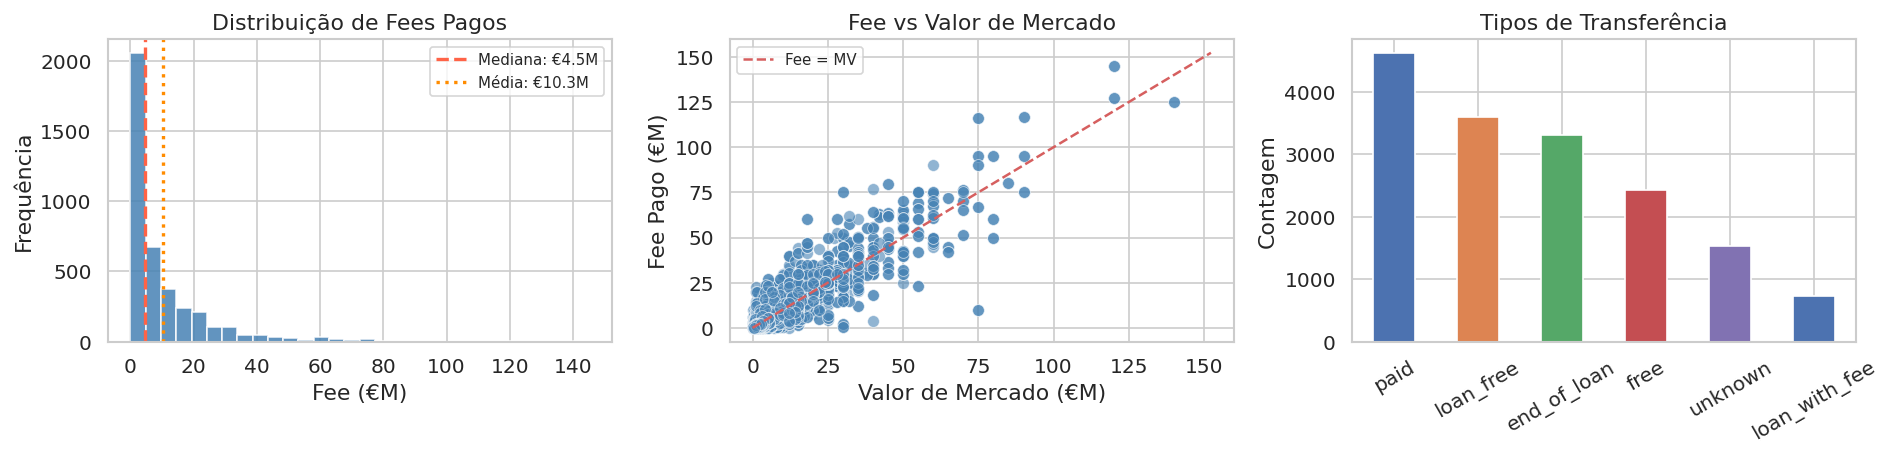

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribuição de fees pagos
ax = axes[0]
vals = df_paid['fee'].dropna() / 1e6
ax.hist(vals, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(vals.median(), color='tomato', lw=2, linestyle='--', label=f'Mediana: €{vals.median():.1f}M')
ax.axvline(vals.mean(), color='darkorange', lw=2, linestyle=':', label=f'Média: €{vals.mean():.1f}M')
ax.set_xlabel('Fee (€M)')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição de Fees Pagos')
ax.legend(fontsize=9)

# Fee vs Valor de mercado
ax = axes[1]
df_both = df_paid.dropna(subset=['fee','market_value'])
ax.scatter(df_both['market_value']/1e6, df_both['fee']/1e6,
           alpha=0.6, s=50, color='steelblue', edgecolors='white', linewidths=0.5)
lim = max(df_both[['fee','market_value']].max()) / 1e6 * 1.05
ax.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Fee = MV')
ax.set_xlabel('Valor de Mercado (€M)')
ax.set_ylabel('Fee Pago (€M)')
ax.set_title('Fee vs Valor de Mercado')
ax.legend(fontsize=9)

# Composição de tipos de transferência
ax = axes[2]
type_counts = df_transfers['fee_type'].value_counts()
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
type_counts.plot(kind='bar', ax=ax, color=colors[:len(type_counts)], edgecolor='white')
ax.set_title('Tipos de Transferência')
ax.set_xlabel('')
ax.set_ylabel('Contagem')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 4. Prêmio bruto: fee vs. valor de mercado (π)

Definimos o **prêmio** como:
$$\pi = \frac{\text{fee} - \text{MV}}{\text{Market Value}} = \frac{\text{fee}}{\text{Market Value}} - 1$$

Um π > 0 indica que o clube comprador pagou **acima** do valor de mercado de referência.

In [20]:
df_pi = df_paid.dropna(subset=['fee','market_value']).copy()
df_pi['pi_pct'] = df_pi['premium_ratio'] * 100

print(f'Transferências com π calculável: {len(df_pi)}')
print(f'\nDistribuição de π (%):')
print(df_pi['pi_pct'].describe().round(1))
print(f'\nPropagação:')
print(f'  π > 0 (pagou acima do MV): {(df_pi["pi_pct"]>0).sum()} ({(df_pi["pi_pct"]>0).mean()*100:.0f}%)')
print(f'  π = 0 (pagou exato MV):    {(df_pi["pi_pct"]==0).sum()}')
print(f'  π < 0 (pagou abaixo MV):   {(df_pi["pi_pct"]<0).sum()} ({(df_pi["pi_pct"]<0).mean()*100:.0f}%)')

Transferências com π calculável: 4008

Distribuição de π (%):
count    4008.0
mean       33.0
std       196.6
min       -99.8
25%       -37.5
50%         0.0
75%        41.7
max      3900.0
Name: pi_pct, dtype: float64

Propagação:
  π > 0 (pagou acima do MV): 1793 (45%)
  π = 0 (pagou exato MV):    286
  π < 0 (pagou abaixo MV):   1929 (48%)


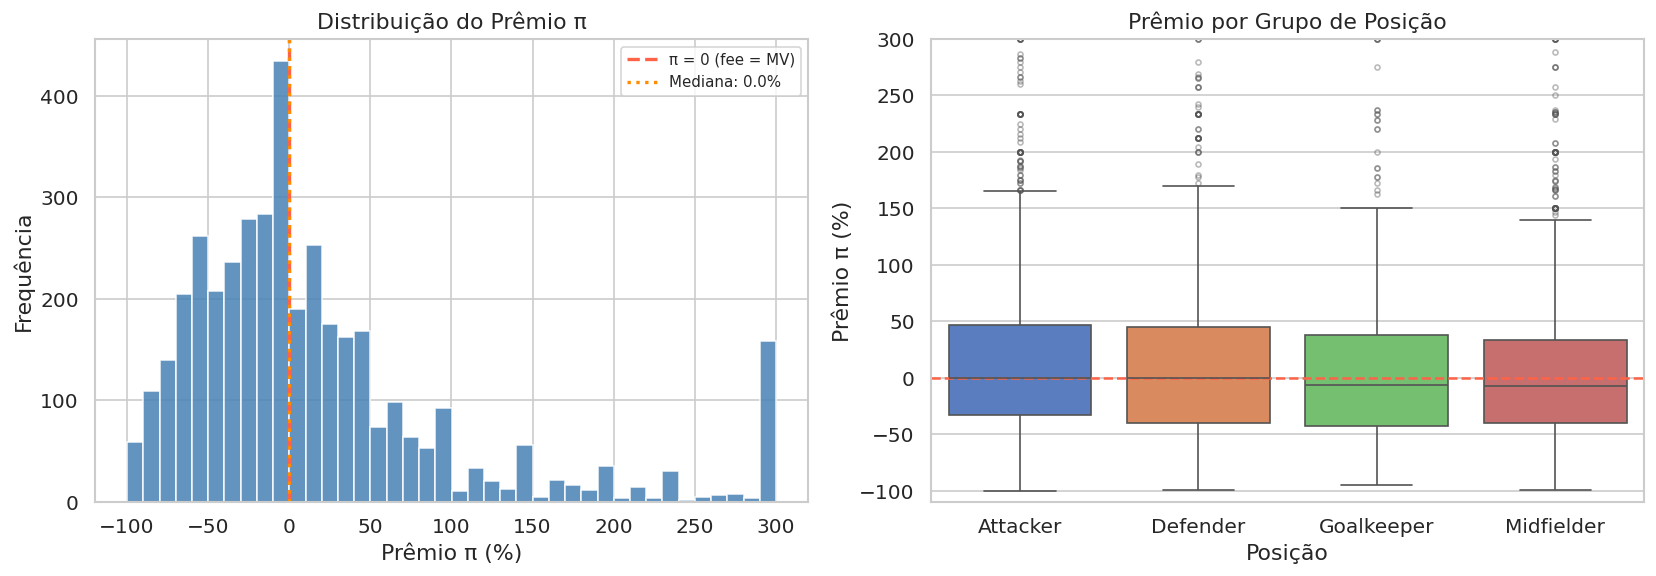

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição de π
ax = axes[0]
clipped = df_pi['pi_pct'].clip(-100, 300)
ax.hist(clipped, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='tomato', lw=2, linestyle='--', label='π = 0 (fee = MV)')
ax.axvline(df_pi['pi_pct'].median(), color='darkorange', lw=2, linestyle=':',
           label=f'Mediana: {df_pi["pi_pct"].median():.1f}%')
ax.set_xlabel('Prêmio π (%)')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição do Prêmio π')
ax.legend(fontsize=9)

# π por grupo de posição
ax = axes[1]
order = df_pi.groupby('position_group')['pi_pct'].median().sort_values(ascending=False).index
sns.boxplot(data=df_pi, x='position_group', y='pi_pct', order=order,
            palette='muted', flierprops=dict(marker='o', markersize=3, alpha=0.4), ax=ax)
ax.axhline(0, color='tomato', lw=1.5, linestyle='--')
ax.set_ylim(-110, 300)
ax.set_xlabel('Posição')
ax.set_ylabel('Prêmio π (%)')
ax.set_title('Prêmio por Grupo de Posição')

plt.tight_layout()
plt.show()

In [41]:
# π médio por clube comprador
buyer_pi = (df_pi.groupby(['buyer', 'source_league', 'season_id'])['pi_pct']
            .agg(['mean','median','count'])
            .rename(columns={'mean':'pi_mean','median':'pi_median','count':'n_compras'})
            .sort_values('pi_mean', ascending=False)
            .reset_index())
buyer_pi['club_label'] = buyer_pi['buyer'] + ' (' + buyer_pi['season_id'].astype(str) + ')'

print('Prêmio médio pago por clube/janela (entradas com fee real e MV):')
print(buyer_pi[['club_label', 'pi_mean', 'pi_median', 'n_compras']].to_string(index=False))

Prêmio médio pago por clube/janela (entradas com fee real e MV):
                     club_label       pi_mean   pi_median  n_compras
                 Chelsea (2024)  1.900000e+03 1900.000000          1
                Juventus (2024)  1.280000e+03 1280.000000          1
           R. Strasbourg (2024)  1.201429e+03  460.000000          4
                Atlético (2023)  9.432222e+02  -12.000000          3
                 NEOM SC (2025)  8.154167e+02   26.666667          4
              Al-Ettifaq (2024)  8.000000e+02  800.000000          1
               FC Vizela (2023)  7.200000e+02  720.000000          2
    RC Strasbourg Alsace (2024)  6.608185e+02  130.000000          8
           R. Strasbourg (2025)  6.500000e+02  650.000000          1
           Athletic Club (2024)  6.500000e+02  650.000000          1
           Cercle Brugge (2025)  6.332333e+02  -20.000000          5
             Galatasaray (2025)  5.500000e+02  550.000000          1
      Atlético de Madrid (2023)  5.278

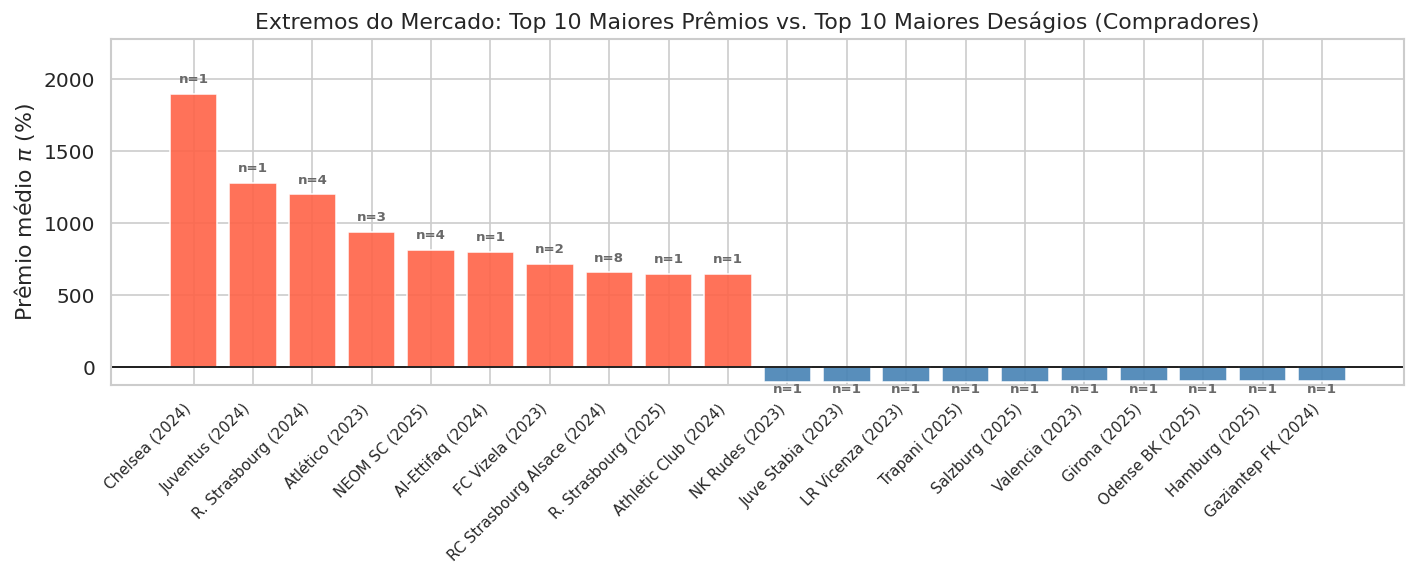

In [42]:
top_pagadores = buyer_pi.sort_values(by='pi_mean', ascending=False).head(10)
top_barganhas = buyer_pi.sort_values(by='pi_mean', ascending=True).head(10)
top_extremos = pd.concat([top_pagadores, top_barganhas]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['tomato' if v > 0 else 'steelblue' for v in top_extremos['pi_mean']]

ax.bar(top_extremos['club_label'], top_extremos['pi_mean'], color=colors, edgecolor='white', alpha=0.9)
ax.axhline(0, color='black', lw=1)
ax.set_xticks(range(len(top_extremos)))
ax.set_xticklabels(top_extremos['club_label'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Prêmio médio $\pi$ (%)')
ax.set_title('Extremos do Mercado: Top 10 Maiores Prêmios vs. Top 10 Maiores Deságios (Compradores)')

for i, row in top_extremos.iterrows():
    val = row['pi_mean']
    va_direction = 'bottom' if val >= 0 else 'top'
    offset = (top_extremos['pi_mean'].max() * 0.03) if val >= 0 else (top_extremos['pi_mean'].min() * 0.05)
    
    ax.text(i, val + offset, f"n={row['n_compras']}", 
            ha='center', va=va_direction, fontsize=8, color='dimgray', fontweight='semibold')

ax.set_ylim(top_extremos['pi_mean'].min() * 1.2, top_extremos['pi_mean'].max() * 1.2)
plt.tight_layout()
plt.show()

## 5. Análise do "prêmio do vendedor" - sinal bruto

Pergunta central: **clubes que também fizeram saídas pagas na mesma janela tendem a pagar prêmios maiores nas entradas?**

In [ ]:
internal_clubs_list = list(df_clubs['club_name'].unique())

sellers_by_season = (
    df_transfers[(df_transfers['direction'] == 'Out') & (df_transfers['fee_type'] == 'paid')]
    .groupby(['source_league', 'season_id'])['club']
    .apply(set)
    .to_dict()
)

def checar_venda_na_janela(row, sellers_dict):
    chave = (row['source_league'], row['season_id'])
    if chave in sellers_dict:
        return row['club'] in sellers_dict[chave]
    return False

In [37]:
revenue_by_club = (
    df_transfers[(df_transfers['direction'] == 'Out') & (df_transfers['fee_type'] == 'paid')]
    .groupby(['club', 'source_league', 'season_id'])['fee']
    .sum()
    .rename('revenue_sales')
    .reset_index()
)


df_pi_in = df_transfers[df_transfers['direction'] == 'In'].copy()
df_pi_in['pi_pct'] = df_pi_in['premium_ratio'] * 100 
df_pi_in = df_pi_in.dropna(subset=['pi_pct'])
df_pi_in['sold_in_window'] = df_pi_in.apply(lambda r: checar_venda_na_janela(r, sellers_by_season), axis=1)
df_pi_in = df_pi_in.merge(
    revenue_by_club, 
    on=['club', 'source_league', 'season_id'], 
    how='left'
)
df_pi_in['revenue_sales'] = df_pi_in['revenue_sales'].fillna(0)

print(f'Entradas com π calculável (Janela Longitudinal): {len(df_pi_in)}')
print(f"- De clubes que venderam na mesma janela: {df_pi_in['sold_in_window'].sum()}")
print(f"- De clubes que não venderam na mesma janela: {(~df_pi_in['sold_in_window']).sum()}")

Entradas com π calculável (Janela Longitudinal): 2488
- De clubes que venderam na mesma janela: 2475
- De clubes que não venderam na mesma janela: 13


In [38]:
grupo_vendeu = df_pi_in[df_pi_in['sold_in_window']]['pi_pct']
grupo_nao_vendeu = df_pi_in[~df_pi_in['sold_in_window']]['pi_pct']

print('π (%) para clubes QUE VENDERAM NA JANELA:')
print(grupo_vendeu.describe().round(1))
print('\nπ (%) para clubes QUE NÃO VENDERAM NA JANELA:')
print(grupo_nao_vendeu.describe().round(1))

diff_mediana = grupo_vendeu.median() - grupo_nao_vendeu.median()
diff_media = grupo_vendeu.mean() - grupo_nao_vendeu.mean()
print(f'Diferença de medianas: {diff_mediana:+.1f} p.p.')
print(f'Diferença de médias: {diff_media:+.1f} p.p.\n')

π (%) para clubes QUE VENDERAM NA JANELA:
count    2475.0
mean       30.0
std       203.7
min       -99.0
25%       -50.0
50%        -6.0
75%        41.1
max      3900.0
Name: pi_pct, dtype: float64

π (%) para clubes QUE NÃO VENDERAM NA JANELA:
count     13.0
mean     -10.1
std       65.3
min      -85.0
25%      -66.7
50%      -20.0
75%        0.0
max      122.2
Name: pi_pct, dtype: float64
Diferença de medianas: +14.0 p.p.
Diferença de médias: +40.1 p.p.



In [43]:
# Teste t de Welch (não assume variâncias iguais)
t_stat, p_val = stats.ttest_ind(grupo_vendeu, grupo_nao_vendeu, equal_var=False)
# Teste de Mann-Whitney U (Unicaudal: hipótese de que quem vendeu paga um prêmio MAIOR)
u_stat, p_mann = stats.mannwhitneyu(grupo_vendeu, grupo_nao_vendeu, alternative='greater')

print(f'Teste t de Welch: t={t_stat:.3f}, p={p_val:.4f}')
print(f'Mann-Whitney U (vendeu > não vendeu): U={u_stat:.0f}, p={p_mann:.4f}\n')
if p_mann < 0.05:
    print('Sinal positivo! Clubes que realizaram saídas tendem a pagar um π significativamente MAIOR (p<0.05).')
elif p_mann < 0.1:
    print('Sinal fraco (0.05 < p < 0.10). Existe uma tendência de comportamento, mas sem significância forte.')
else:
    print('Sem sinal claro nos dados brutos. Confundidores econômicos provavelmente dominam essa relação.')

print('\nNota: Esta é uma análise estatística bruta agregada unificando múltiplos anos/ligas.')
print('Ela aponta a tendência macro do ecossistema, mas necessita do controle dos efeitos fixos (C1-C6 da proposta).')

Teste t de Welch: t=2.160, p=0.0496
Mann-Whitney U (vendeu > não vendeu): U=18050, p=0.2238

Sem sinal claro nos dados brutos. Confundidores econômicos provavelmente dominam essa relação.

Nota: Esta é uma análise estatística bruta agregada unificando múltiplos anos/ligas.
Ela aponta a tendência macro do ecossistema, mas necessita do controle dos efeitos fixos (C1-C6 da proposta).


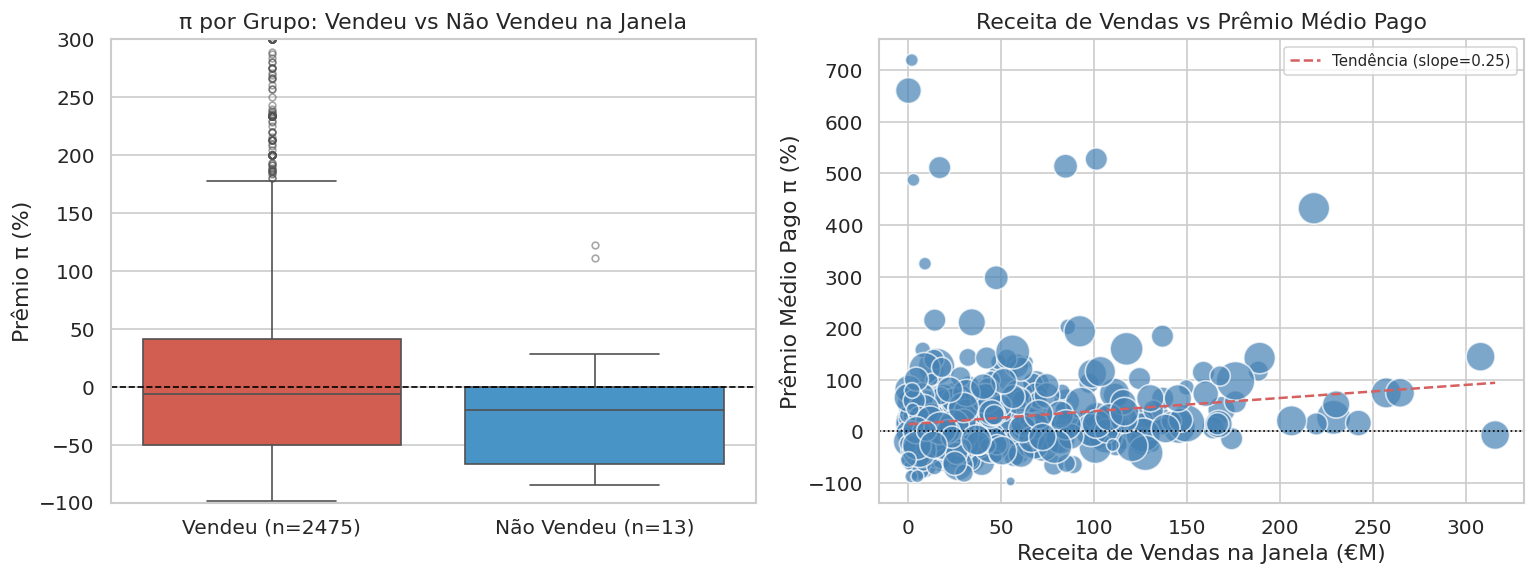

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
df_plot = df_pi_in.copy()
df_plot['Grupo'] = df_plot['sold_in_window'].map({
    True: 'Vendeu (n={})'.format(len(grupo_vendeu)),
    False: 'Não Vendeu (n={})'.format(len(grupo_nao_vendeu))
})

sns.boxplot(data=df_plot, x='Grupo', y='pi_pct',
            palette=['#e74c3c','#3498db'], flierprops=dict(marker='o', markersize=4, alpha=0.5), ax=ax)
ax.axhline(0, color='black', lw=1, linestyle='--')
ax.set_ylim(-100, 300) 
ax.set_ylabel('Prêmio π (%)')
ax.set_title('π por Grupo: Vendeu vs Não Vendeu na Janela')
ax.set_xlabel('')

ax = axes[1]
scatter_data = (df_pi_in.groupby(['buyer', 'source_league', 'season_id'])
                .agg(
                    pi_mean=('pi_pct', 'mean'), 
                    revenue=('revenue_sales', 'first'), 
                    n=('pi_pct', 'count')
                )
                .reset_index())

ax.scatter(scatter_data['revenue']/1e6, scatter_data['pi_mean'],
           s=scatter_data['n']*30, alpha=0.7, color='steelblue', edgecolors='white')

m, b = np.polyfit(scatter_data['revenue']/1e6, scatter_data['pi_mean'], 1)
x_line = np.linspace(0, scatter_data['revenue'].max()/1e6, 100)
ax.plot(x_line, m*x_line + b, 'r--', lw=1.5, label=f'Tendência (slope={m:.2f})')
ax.axhline(0, color='black', lw=1, linestyle=':')
ax.set_xlabel('Receita de Vendas na Janela (€M)')
ax.set_ylabel('Prêmio Médio Pago π (%)')
ax.set_title('Receita de Vendas vs Prêmio Médio Pago')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 6. Análise de rede: grafo de transferências

In [ ]:
# Criamos uma lista para armazenar os DataFrames de métricas de cada temporada
dfs_metricas_temporais = []

# Mapeamos todos os clubes originais das ligas 
internal_clubs = set(df_clubs['club_name'].unique())

# Um grafo isolado para cada temporada
for season in df_transfers['season_id'].unique():
    
    # 1. Isolar os dados de transferências pagas daquela temporada específica
    df_season = df_transfers[
        (df_transfers['fee_type'] == 'paid') & 
        (df_transfers['season_id'] == season)
    ].copy()
    
    # Inicializa o Grafo Dirigido da temporada correspondente
    G_season = nx.DiGraph()
    
    # Adicionar os nós base
    for club in internal_clubs:
        G_season.add_node(club, internal_ecosystem=True)
        
    # 2. Adicionar as arestas (fluxos financeiros) daquela temporada específica
    for _, row in df_season.iterrows():
        buyer  = row['buyer']
        seller = row['seller']
        fee    = row['fee'] if pd.notna(row['fee']) else 0
        
        if pd.notna(buyer) and pd.notna(seller) and buyer != seller:
            # Garante que clubes de fora mapeados naquela janela entrem com a flag False
            if not G_season.has_node(buyer):
                G_season.add_node(buyer, internal_ecosystem=False)
            if not G_season.has_node(seller):
                G_season.add_node(seller, internal_ecosystem=False)
                
            # Acumula os valores dentro da mesma temporada
            if G_season.has_edge(seller, buyer):
                G_season[seller][buyer]['weight'] += fee
                G_season[seller][buyer]['n_transfers'] += 1
            else:
                G_season.add_edge(seller, buyer, weight=fee, n_transfers=1)
                
    # Diagnóstico rápido da janela no terminal 
    print(f"[Temporada {season}] Grafo gerado: {G_season.number_of_nodes()} nós | {G_season.number_of_edges()} arestas")
                
    centrality_season = {}
    for club in internal_clubs:
        if club in G_season:
            # Força de entrada (investimento) e saída (arrecadação) ponderadas pelo valor (€)
            in_strength = G_season.in_degree(club, weight='weight')
            out_strength = G_season.out_degree(club, weight='weight')
            
            centrality_season[club] = {
                'in_degree': G_season.in_degree(club),
                'out_degree': G_season.out_degree(club),
                'in_strength': in_strength,
                'out_strength': out_strength,
                'net_flow': in_strength - out_strength  # Balanço financeiro líquido na rede
            }
            
    # Converte os resultados da temporada em DataFrame e injeta a chave temporal
    df_season_net = pd.DataFrame(centrality_season).T.reset_index().rename(columns={'index': 'club'})
    df_season_net['season_id'] = season  
    dfs_metricas_temporais.append(df_season_net)

# Junta os resultados de todas as janelas em uma única tabela 
df_net_longitudinal = pd.concat(dfs_metricas_temporais, ignore_index=True)
# Ordena cronologicamente e coloca os clubes que mais gastaram no topo
df_net_longitudinal = df_net_longitudinal.sort_values(['season_id', 'in_strength'], ascending=[True, False])

print('DataFrame Longitudinal de Redes Concluído com Sucesso!')
print('Dimensões finais (linhas x colunas):', df_net_longitudinal.shape)

[Temporada 2025] Grafo gerado: 834 nós | 1584 arestas
[Temporada 2023] Grafo gerado: 790 nós | 1418 arestas
[Temporada 2024] Grafo gerado: 807 nós | 1404 arestas
DataFrame Longitudinal de Redes Concluído com Sucesso!
Dimensões finais (linhas x colunas): (822, 7)


In [57]:
dfs_centralidade_temporais = []
internal_clubs = set(df_clubs['club_name'].unique())

for season in df_transfers['season_id'].unique():
    
    df_season = df_transfers[(df_transfers['fee_type'] == 'paid') & (df_transfers['season_id'] == season)]
    G_season = nx.DiGraph()
    for club in internal_clubs:
        G_season.add_node(club, internal_ecosystem=True)
    
    for _, row in df_season.iterrows():
        buyer, seller, fee = row['buyer'], row['seller'], row['fee']
        if pd.notna(buyer) and pd.notna(seller) and buyer != seller:
            if not G_season.has_node(buyer): G_season.add_node(buyer, internal_ecosystem=False)
            if not G_season.has_node(seller): G_season.add_node(seller, internal_ecosystem=False)
            
            if G_season.has_edge(seller, buyer):
                G_season[seller][buyer]['weight'] += fee if pd.notna(fee) else 0
            else:
                G_season.add_edge(seller, buyer, weight=fee if pd.notna(fee) else 0)

    centrality_metrics = {}
    for club in internal_clubs:
        if club in G_season:
            in_strength = G_season.in_degree(club, weight='weight')
            out_strength = G_season.out_degree(club, weight='weight')
            
            centrality_metrics[club] = {
                'in_degree': G_season.in_degree(club),
                'out_degree': G_season.out_degree(club),
                'in_strength': in_strength,
                'out_strength': out_strength,
                'net_flow': in_strength - out_strength 
            }
    
    df_season_net = pd.DataFrame(centrality_metrics).T.reset_index().rename(columns={'index': 'club'})
    df_season_net['season_id'] = season
    dfs_centralidade_temporais.append(df_season_net)

df_net = pd.concat(dfs_centralidade_temporais, ignore_index=True)
df_net = df_net.sort_values(['season_id', 'in_strength'], ascending=[True, False])
print('Indicadores de Posição Estrutural na Rede Dinâmica (Painel Longitudinal):')
print(df_net[['season_id', 'club', 'in_degree', 'out_degree', 'in_strength', 'out_strength', 'net_flow']].head(15).to_string(index=False))

Indicadores de Posição Estrutural na Rede Dinâmica (Painel Longitudinal):
 season_id                club  in_degree  out_degree  in_strength  out_strength    net_flow
      2023 Paris Saint-Germain       11.0        10.0  454500000.0   206150000.0 248350000.0
      2023          Chelsea FC        9.0         8.0  448100000.0   264600000.0 183500000.0
      2023       Bayern Munich        6.0        10.0  325000000.0   317220000.0   7780000.0
      2023         Real Madrid        4.0         3.0  292000000.0    14000000.0 278000000.0
      2023   Tottenham Hotspur        9.0         3.0  275100000.0   116100000.0 159000000.0
      2023     Manchester City        5.0         5.0  259600000.0   131800000.0 127800000.0
      2023          Arsenal FC        3.0         6.0  231600000.0    66350000.0 165250000.0
      2023            AC Milan       12.0         7.0  218180000.0   137150000.0  81030000.0
      2023   Manchester United        4.0         7.0  202700000.0    60770000.0 14193000

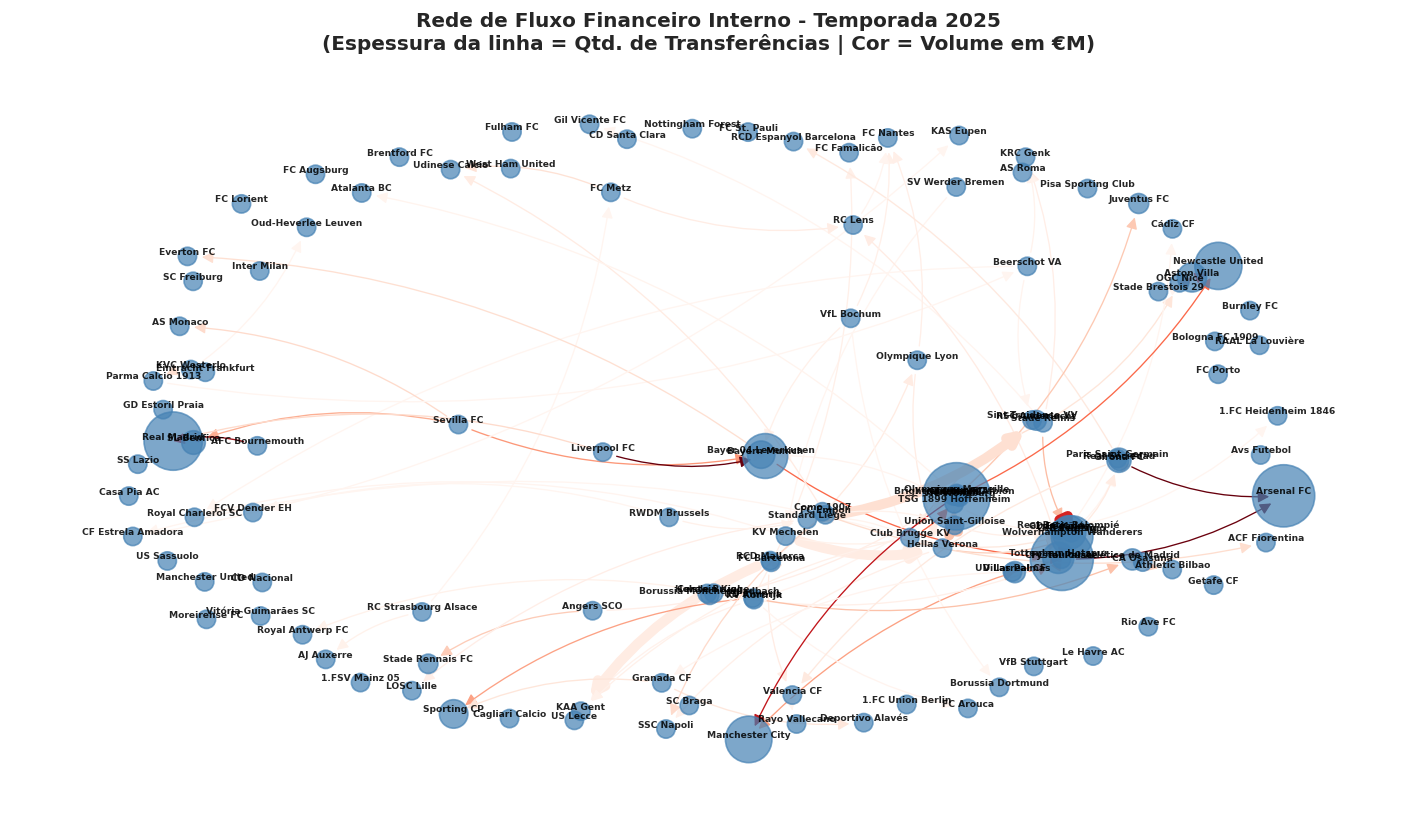

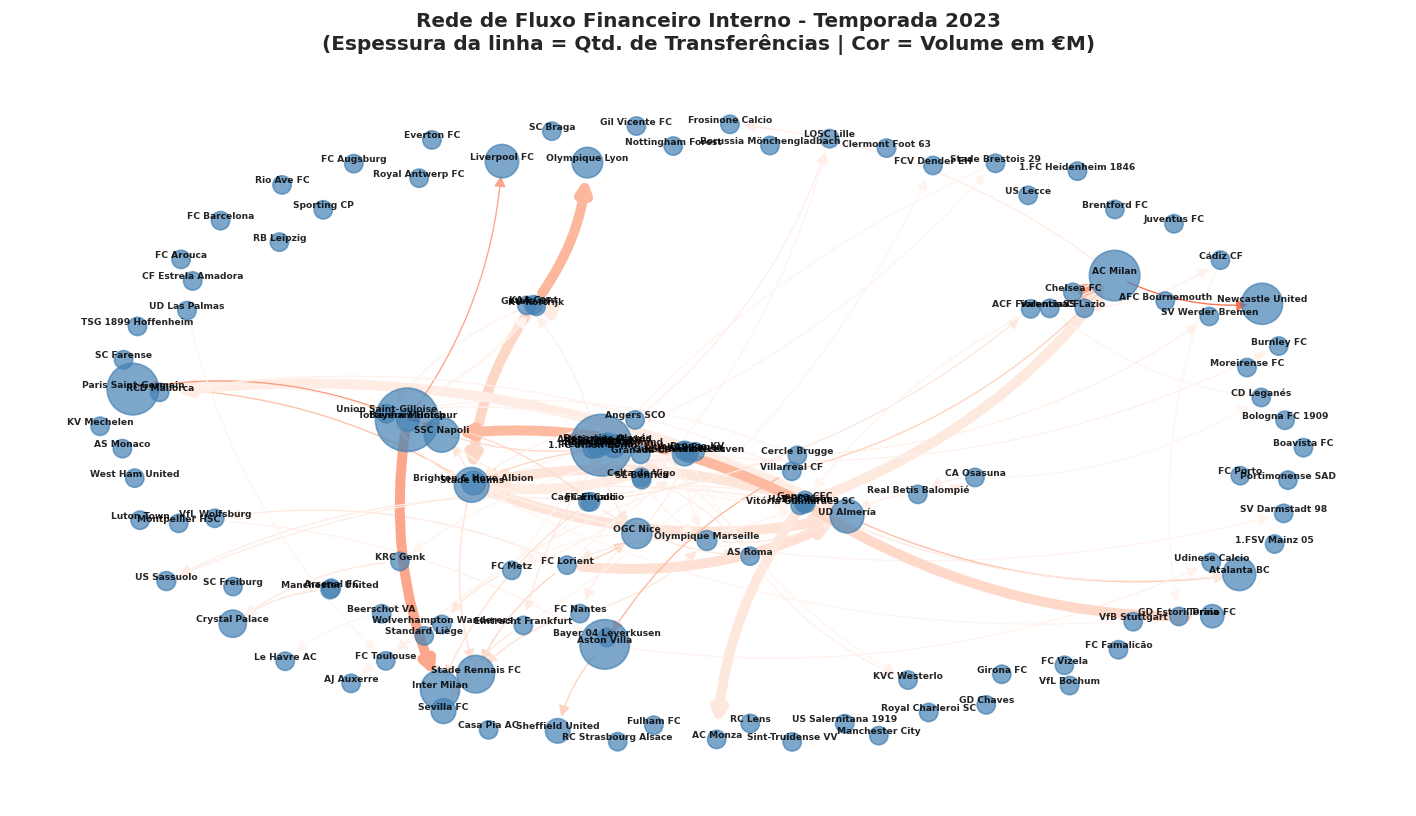

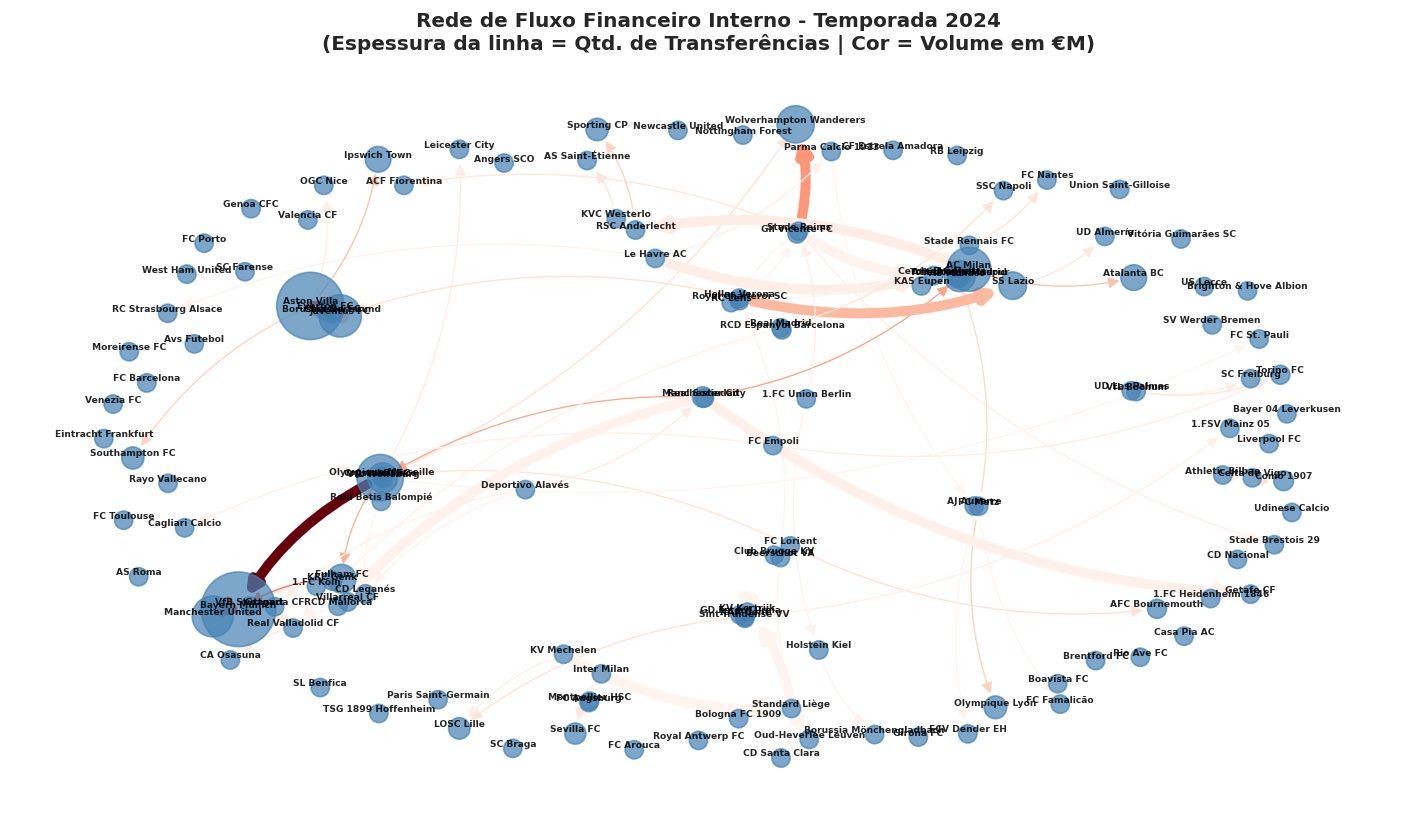

In [ ]:
internal_clubs_list = list(df_clubs['club_name'].unique())
for season in df_transfers['season_id'].unique():
    df_season = df_transfers[
        (df_transfers['fee_type'] == 'paid') & 
        (df_transfers['season_id'] == season)
    ].copy()
    G_temp = nx.DiGraph()
    for _, row in df_season.iterrows():
        buyer, seller, fee = row['buyer'], row['seller'], row['fee']
        if pd.notna(buyer) and pd.notna(seller) and buyer != seller:
            if G_temp.has_edge(seller, buyer):
                G_temp[seller][buyer]['weight'] += fee if pd.notna(fee) else 0
                G_temp[seller][buyer]['n_transfers'] += 1  # Incrementa contagem de transações
            else:
                G_temp.add_edge(seller, buyer, weight=fee if pd.notna(fee) else 0, n_transfers=1)
 
    nodes_presente = [c for c in internal_clubs_list if c in G_temp]
    H = G_temp.subgraph(nodes_presente).copy()

    fig, ax = plt.subplots(figsize=(12, 7))
    if H.number_of_edges() > 0:
        pos = nx.spring_layout(H, seed=42, k=2.5)
        in_strengths = dict(H.in_degree(weight='weight'))
        node_sizes = [max(120, in_strengths.get(n, 0) / 1e5) for n in H.nodes]
        nx.draw_networkx_nodes(H, pos, node_size=node_sizes, node_color='steelblue', alpha=0.7, ax=ax)

        labels_todos = {n: n for n in H.nodes}

        nx.draw_networkx_labels(H, pos, labels=labels_todos, 
                                font_size=5.5, font_weight='bold', 
                                font_color='black', alpha=0.85,
                                verticalalignment='bottom', ax=ax)
        
        edges = H.edges(data=True)
    
        num_transfers = [d['n_transfers'] for _, _, d in edges]
        max_transfers = max(num_transfers) if num_transfers else 1
        edge_widths = [0.8 + (5.2 * (nt - 1) / max(1, max_transfers - 1)) if max_transfers > 1 else 1.5 for nt in num_transfers]
        
        weights = [d['weight'] / 1e6 for _, _, d in edges]
        
        nx.draw_networkx_edges(H, pos,
                               width=edge_widths,
                               edge_color=weights, edge_cmap=plt.cm.Reds,
                               arrows=True, arrowsize=14,
                               connectionstyle='arc3,rad=0.15', ax=ax)
            
        ax.set_title(f'Rede de Fluxo Financeiro Interno - Temporada {season}\n'
                     f'(Espessura da linha = Qtd. de Transferências | Cor = Volume em €M)', 
                     fontsize=12, fontweight='bold')
    else:
        ax.text(0.5, 0.5, f'Sem movimentações diretas internas registradas na temporada {season}.',
                ha='center', va='center', transform=ax.transAxes, fontsize=11, color='gray')
        ax.set_title(f'Rede de Fluxo Interno - Temporada {season}', fontsize=12, fontweight='bold')
        
    ax.axis('off')
    plt.tight_layout()
    plt.show()

Linha Grossa e Vermelha Escura: Os clubes negociaram muitos jogadores e gastaram muito dinheiro - parceria comercial forte.

Linha Grossa e Vermelha Clara: Os clubes negociaram vários jogadores, mas por valores muito baixos - provavelmente trocas de jogadores da base ou atletas em fim de contrato.

Linha Fina e Vermelha Escura: Houve apenas uma única transferência entre os clubes, mas ela foi uma contratação de alto valor - um caso isolado que injetou muito dinheiro de uma vez só no vendedor

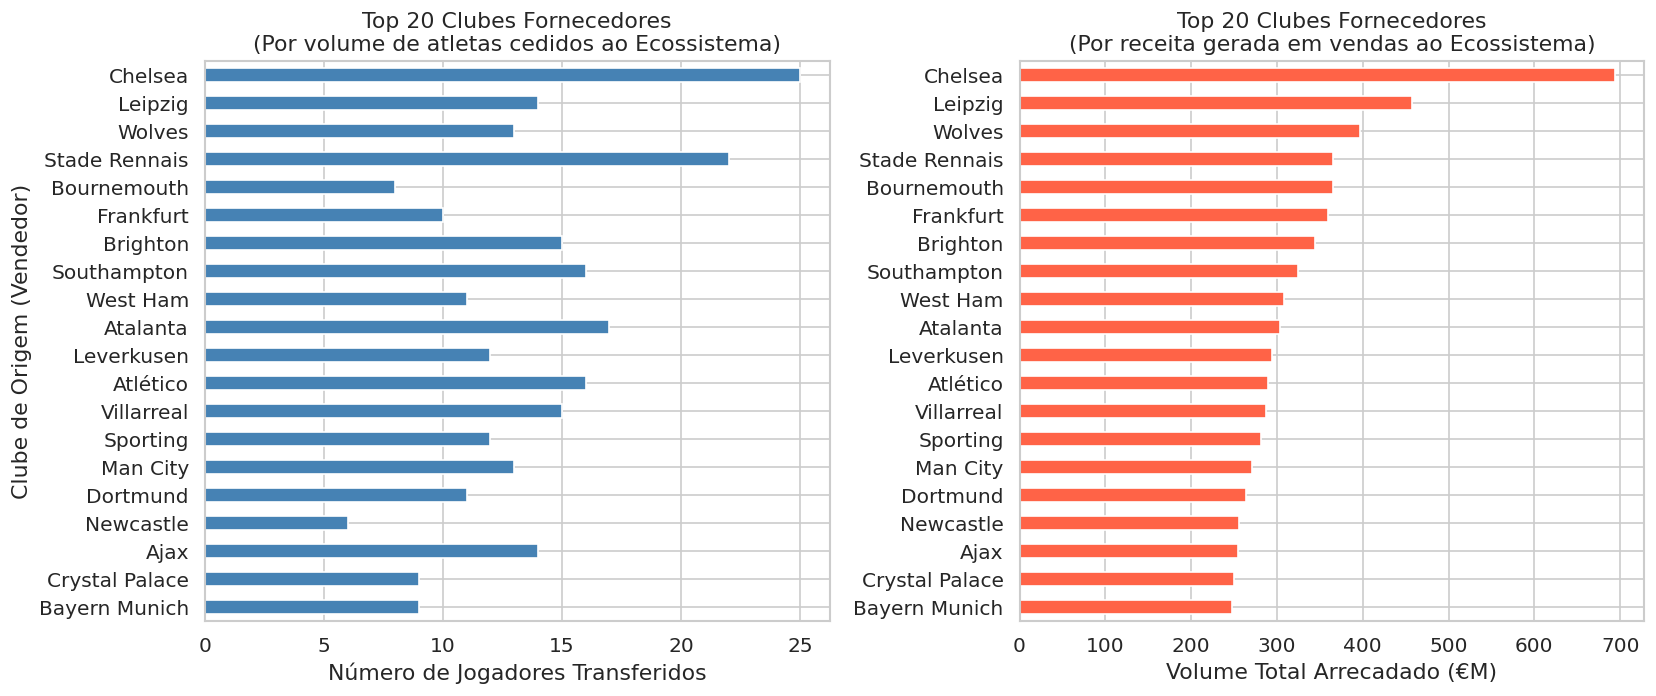

In [63]:
df_paid_in = df_transfers[
    (df_transfers['fee_type'] == 'paid') & 
    (df_transfers['buyer'].isin(internal_clubs_list))
].copy()

origin_counts = (df_paid_in.groupby('seller')
                 .agg(
                     n_players=('player', 'count'),
                     total_fee=('fee', 'sum')
                 )
                 .sort_values('total_fee', ascending=False)
                 .head(20)) 

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
origin_counts['n_players'].plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Número de Jogadores Transferidos')
ax.set_ylabel('Clube de Origem (Vendedor)')
ax.set_title('Top 20 Clubes Fornecedores\n(Por volume de atletas cedidos ao Ecossistema)')
ax.invert_yaxis()  

ax = axes[1]
(origin_counts['total_fee']/1e6).plot(kind='barh', ax=ax, color='tomato', edgecolor='white')
ax.set_xlabel('Volume Total Arrecadado (€M)')
ax.set_ylabel('')  
ax.set_title('Top 20 Clubes Fornecedores\n(Por receita gerada em vendas ao Ecossistema)')
ax.invert_yaxis()  

plt.tight_layout()
plt.show()

## 7. Perfil dos jogadores transferidos

In [67]:
internal_clubs_list = list(df_clubs['club_name'].unique())

df_paid_in = df_transfers[
    (df_transfers['fee_type'] == 'paid') & 
    (df_transfers['buyer'].isin(internal_clubs_list))
].copy()

origin_counts = (df_paid_in.groupby('seller')
                 .agg(
                     n_players=('player', 'count'),
                     total_fee=('fee', 'sum')
                 )
                 .sort_values('total_fee', ascending=False)
                 .head(20))

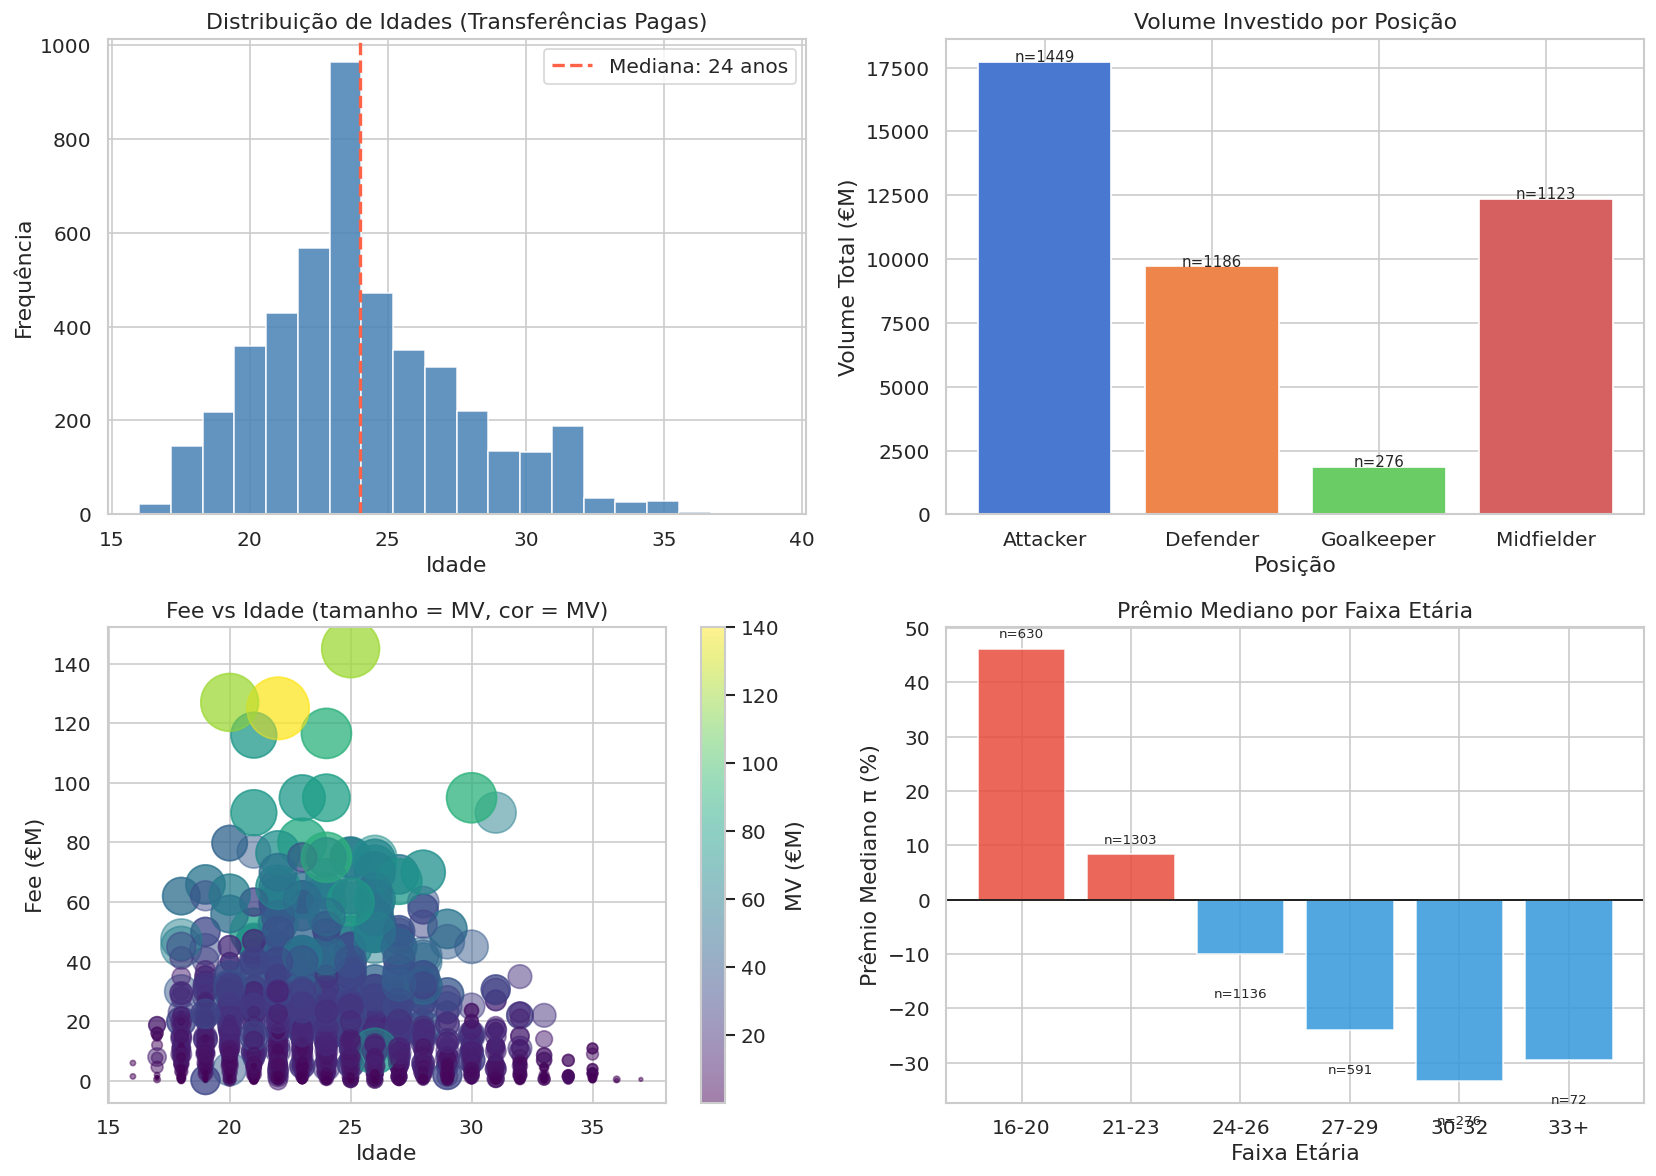

In [68]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribuição de idades nas transferências pagas
ax = axes[0,0]
df_paid['age'].dropna().hist(bins=20, ax=ax, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df_paid['age'].median(), color='tomato', lw=2, linestyle='--',
           label=f'Mediana: {df_paid["age"].median():.0f} anos')
ax.set_xlabel('Idade')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição de Idades (Transferências Pagas)')
ax.legend()

# 2. Volume por posição
ax = axes[0,1]
pos_vol = (df_paid.groupby('position_group')
           .agg(total_fee=('fee','sum'), n=('fee','count'))
           .reset_index())
colors = sns.color_palette('muted', len(pos_vol))
bars = ax.bar(pos_vol['position_group'], pos_vol['total_fee']/1e6, color=colors, edgecolor='white')
for bar, n in zip(bars, pos_vol['n']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'n={n}', ha='center', fontsize=9)
ax.set_xlabel('Posição')
ax.set_ylabel('Volume Total (€M)')
ax.set_title('Volume Investido por Posição')

# 3. Fee médio vs idade (scatter com tamanho = market_value)
ax = axes[1,0]
df_both = df_paid.dropna(subset=['fee','market_value','age'])
sc = ax.scatter(df_both['age'], df_both['fee']/1e6,
                s=df_both['market_value']/1e5, alpha=0.5,
                c=df_both['market_value']/1e6, cmap='viridis')
plt.colorbar(sc, ax=ax, label='MV (€M)')
ax.set_xlabel('Idade')
ax.set_ylabel('Fee (€M)')
ax.set_title('Fee vs Idade (tamanho = MV, cor = MV)')

# 4. Prêmio π por faixa etária
ax = axes[1,1]
df_pi_age = df_pi.copy()
df_pi_age['age_bin'] = pd.cut(df_pi_age['age'], bins=[15,20,23,26,29,32,40],
                               labels=['16-20','21-23','24-26','27-29','30-32','33+'])
age_pi = df_pi_age.groupby('age_bin', observed=True)['pi_pct'].agg(['median','mean','count']).reset_index()
ax.bar(age_pi['age_bin'].astype(str), age_pi['median'],
       color=['#e74c3c' if v > 0 else '#3498db' for v in age_pi['median']],
       edgecolor='white', alpha=0.85)
ax.axhline(0, color='black', lw=1)
for i, row in age_pi.iterrows():
    ax.text(i, row['median'] + (2 if row['median'] >= 0 else -8),
            f"n={row['count']:.0f}", ha='center', fontsize=8)
ax.set_xlabel('Faixa Etária')
ax.set_ylabel('Prêmio Mediano π (%)')
ax.set_title('Prêmio Mediano por Faixa Etária')

plt.tight_layout()
plt.show()

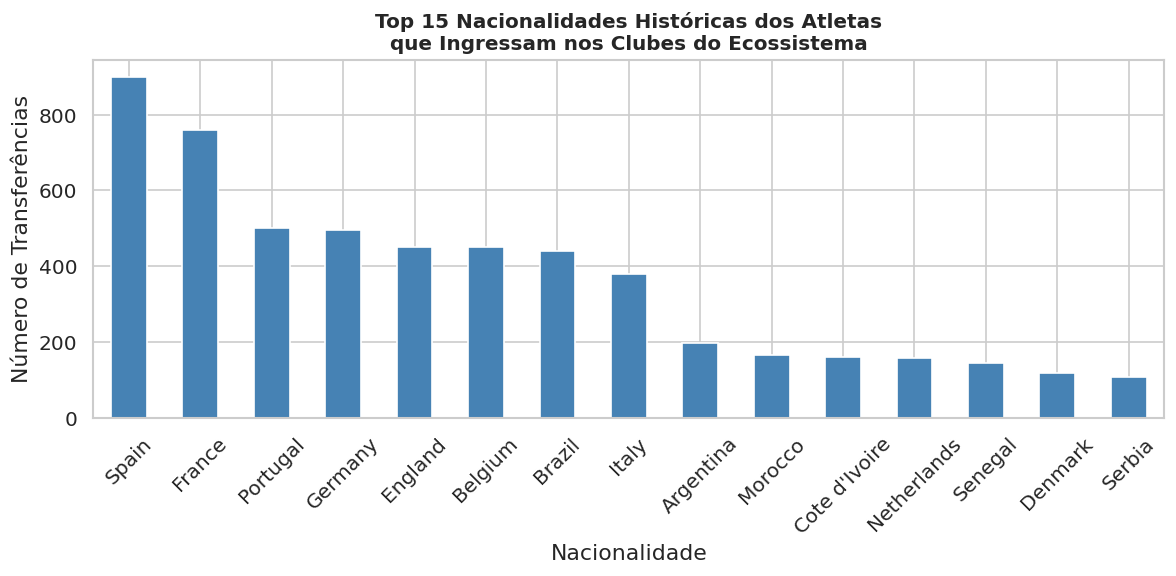

In [71]:
internal_clubs_list = list(df_clubs['club_name'].unique())
df_internal_inputs = df_transfers[df_transfers['buyer'].isin(internal_clubs_list)].copy()
nat_counts = df_internal_inputs['nationality'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
nat_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Nacionalidade')
ax.set_ylabel('Número de Transferências')
ax.set_title('Top 15 Nacionalidades Históricas dos Atletas\nque Ingressam nos Clubes do Ecossistema', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Saldo líquido dos clubes e perfil comprador/vendedor

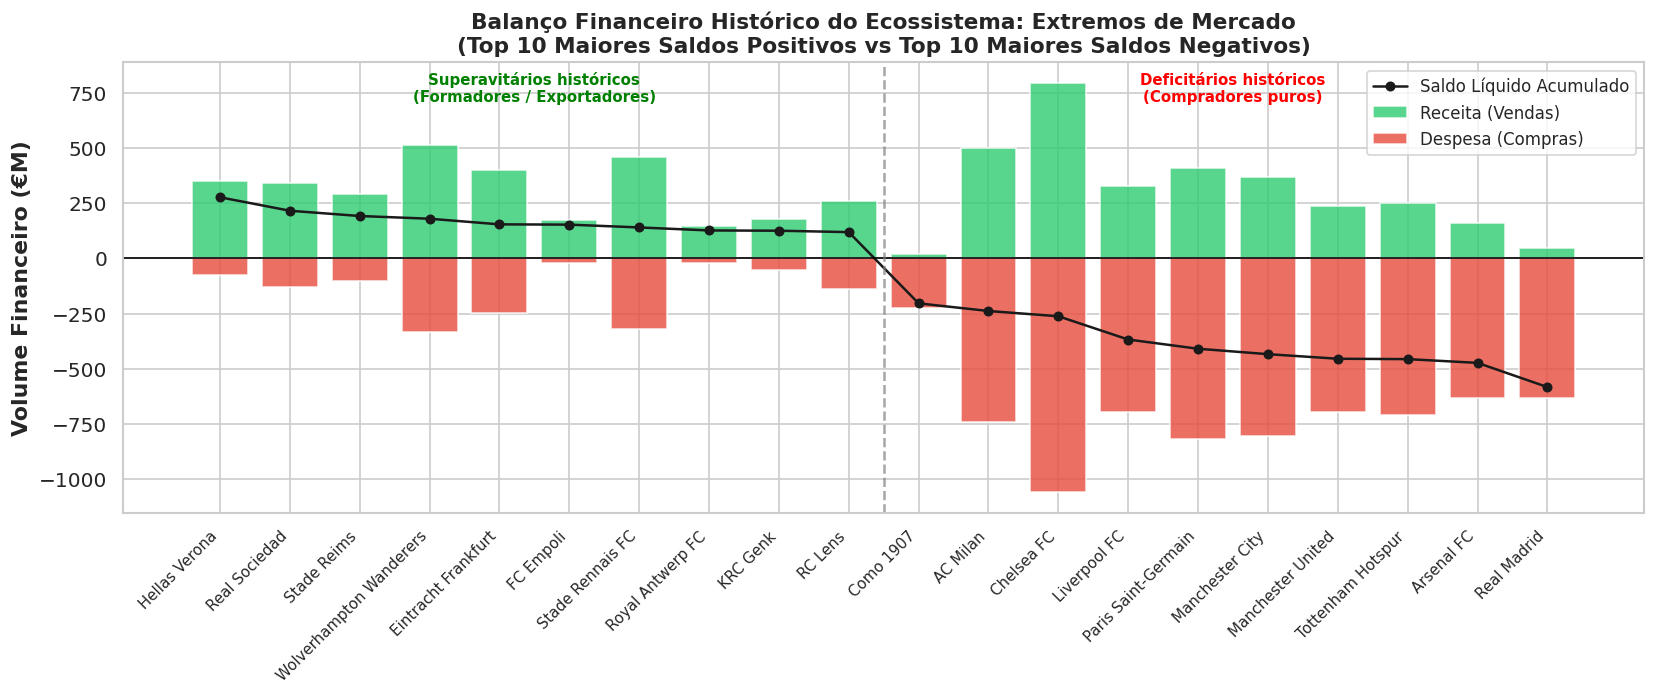


Detalhes dos Saldos Líquidos Acumulados (€M):
Hellas Verona              278.06
Real Sociedad              216.90
Stade Reims                193.00
Wolverhampton Wanderers    180.60
Eintracht Frankfurt        155.04
FC Empoli                  153.79
Stade Rennais FC           141.03
Royal Antwerp FC           127.35
KRC Genk                   126.15
RC Lens                    119.78
Como 1907                 -203.82
AC Milan                  -238.56
Chelsea FC                -262.40
Liverpool FC              -368.15
Paris Saint-Germain       -409.97
Manchester City           -434.62
Manchester United         -455.43
Tottenham Hotspur         -457.15
Arsenal FC                -474.17
Real Madrid               -584.00


In [74]:
internal_clubs_list = list(df_clubs['club_name'].unique())
spend_buy = (df_transfers[(df_transfers['fee_type'] == 'paid') & (df_transfers['buyer'].isin(internal_clubs_list))]
             .groupby('buyer')['fee'].sum().rename('spend'))

rev_sell = (df_transfers[(df_transfers['fee_type'] == 'paid') & (df_transfers['seller'].isin(internal_clubs_list))]
            .groupby('seller')['fee'].sum().rename('revenue'))

df_balance = pd.DataFrame({'spend': spend_buy, 'revenue': rev_sell}).fillna(0)
df_balance['net'] = df_balance['revenue'] - df_balance['spend']
df_lucro = df_balance.sort_values('net', ascending=False).head(10)
df_gasto = df_balance.sort_values('net', ascending=True).head(10).iloc[::-1] # Inverte para o pior ficar na ponta
df_plot_extremos = pd.concat([df_lucro, df_gasto])

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(df_plot_extremos))
ax.bar(x, df_plot_extremos['revenue']/1e6, label='Receita (Vendas)', color='#2ecc71', alpha=0.8, edgecolor='white')
ax.bar(x, -df_plot_extremos['spend']/1e6, label='Despesa (Compras)', color='#e74c3c', alpha=0.8, edgecolor='white')
ax.plot(x, df_plot_extremos['net']/1e6, 'ko-', lw=1.5, ms=5, label='Saldo Líquido Acumulado')
ax.axhline(0, color='black', lw=1)
ax.axvline(9.5, color='gray', linestyle='--', alpha=0.7) 
ax.set_xticks(list(x))
ax.set_xticklabels(df_plot_extremos.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Volume Financeiro (€M)', fontweight='bold')
ax.set_title('Balanço Financeiro Histórico do Ecossistema: Extremos de Mercado\n'
             '(Top 10 Maiores Saldos Positivos vs Top 10 Maiores Saldos Negativos)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.text(4.5, ax.get_ylim()[1]*0.8, "Superavitários históricos\n(Formadores / Exportadores)", ha='center', color='green', fontsize=9, fontweight='bold')
ax.text(14.5, ax.get_ylim()[1]*0.8, "Deficitários históricos\n(Compradores puros)", ha='center', color='red', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nDetalhes dos Saldos Líquidos Acumulados (€M):')
print((df_plot_extremos['net']/1e6).round(2).to_string())

## 9. Correlação entre variáveis para modelo hedônico

Exploramos quais variáveis mais se correlacionam com o fee

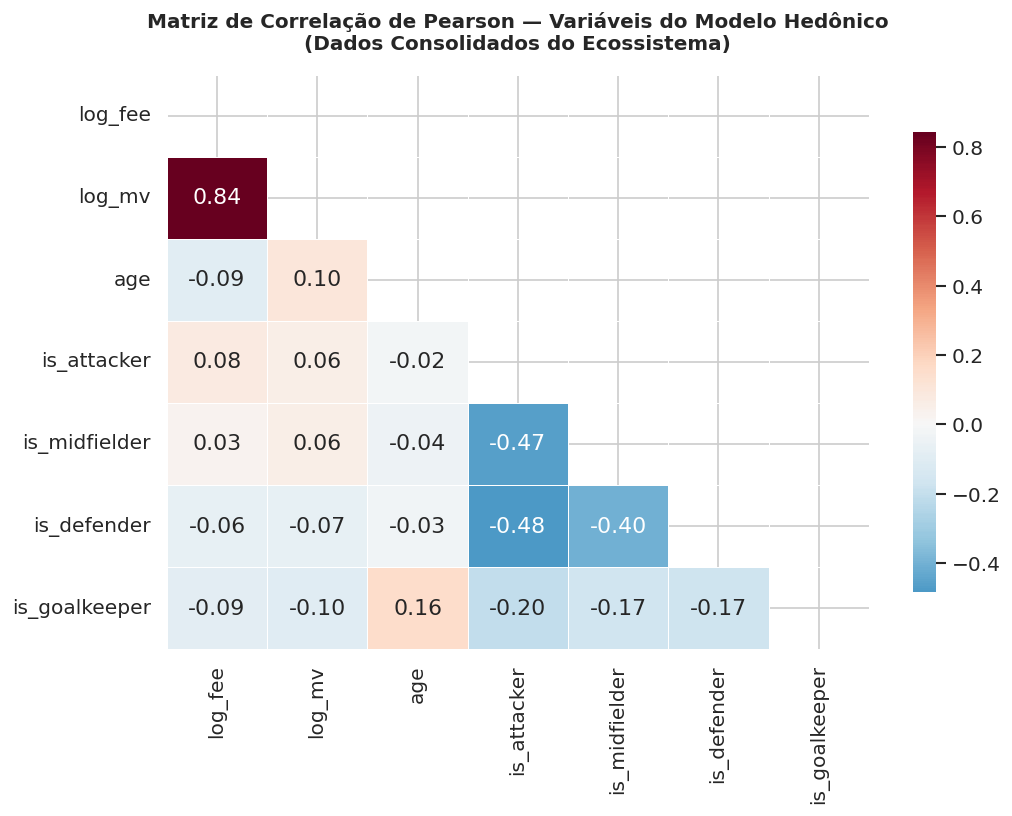

Força de Associação Linear com a Variável Dependente (log_fee):
log_fee          1.000
log_mv           0.843
is_attacker      0.077
is_midfielder    0.033
is_defender     -0.064
is_goalkeeper   -0.089
age             -0.091
Name: log_fee, dtype: float64


In [75]:
df_paid_base = df_transfers[df_transfers['fee_type'] == 'paid'].copy()
df_hedonic = df_paid_base.dropna(subset=['fee', 'market_value', 'age']).copy()
df_hedonic['log_fee'] = np.log1p(df_hedonic['fee'])
df_hedonic['log_mv']  = np.log1p(df_hedonic['market_value'])

df_hedonic['is_attacker']   = (df_hedonic['position_group'] == 'Attacker').astype(int)
df_hedonic['is_midfielder']  = (df_hedonic['position_group'] == 'Midfielder').astype(int)
df_hedonic['is_defender']   = (df_hedonic['position_group'] == 'Defender').astype(int)
df_hedonic['is_goalkeeper'] = (df_hedonic['position_group'] == 'Goalkeeper').astype(int)

corr_cols = ['log_fee', 'log_mv', 'age', 'is_attacker', 'is_midfielder', 'is_defender', 'is_goalkeeper']
corr_matrix = df_hedonic[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title('Matriz de Correlação de Pearson — Variáveis do Modelo Hedônico\n(Dados Consolidados do Ecossistema)', 
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print('Força de Associação Linear com a Variável Dependente (log_fee):')
print(corr_matrix['log_fee'].sort_values(ascending=False).round(3))

### Estimação Econômica do Prêmio de Mercado via Regressão Hedônica

Para descobrir se a posição de um clube na rede de transferências faz ele pagar mais caro por um jogador, nós precisamos primeiro isolar o "preço justo" do atleta baseado em suas características. Para isso, criamos uma fórmula matemática chamada **Regressão Hedônica**, utilizando o método de Mínimos Quadrados Ordinários (OLS) através da biblioteca `statsmodels`. Essa fórmula calcula o preço esperado de um jogador combinando seus fundamentos básicos (como idade, posição e valor de mercado). A diferença entre o que o clube realmente pagou e o preço que a fórmula estimou é o nosso **prêmio $\pi$** (o valor inflacionado), que serve como a pista principal para mapear o efeito dominó.

A variável dependente do modelo foi definida como o logaritmo natural do valor pago pela transferência, dada por $\ln(\text{fee} + 1)$. Esta é uma transformação matemática padrão na literatura de economia do esporte para estabilizar a variância e corrigir a assimetria presente na distribuição de valores monetários do futebol.

Como variáveis independentes explicativas (que representam os fundamentos mercadológicos e biológicos do atleta), o modelo abstraiu:
* O logaritmo natural do valor de mercado estimado pré-transferência ($\ln(\text{market\_value} + 1)$);
* A idade do atleta (`age`);
* Variáveis *dummies* indicadoras para os grupos de posição de linha (`is_attacker`, `is_midfielder` e `is_defender`), utilizando a posição de goleiro (`Goalkeeper`) como categoria de referência omitida para evitar a armadilha da multicolinearidade perfeita.

### A Inclusão das Variáveis de Controle Temporário (Efeitos Fixos de Tempo)

O principal refinamento na metodologia desta função foi a inclusão de **variáveis de controle para as temporadas** (`season_id`), transformadas em *dummies* no modelo global. 

> **Nota Metodológica:** Em modelos econométricos aplicados a dados em painel longitudinal, o mercado de transferências não pode ser tratado de forma homogênea ao longo dos anos. Fatores macroeconômicos externos, como alterações nas regras de *Fair Play* Financeiro, injeção global de capital por novos fundos de investimento, inflação natural da indústria ou variações cambiais, criam choques de liquidez que afetam os preços de todas as transações de uma janela, independentemente da qualidade individual dos atletas envolvidos.

Ao introduzir os **Efeitos Fixos de Tempo** (as *dummies* de temporada), o modelo passa a comparar um jogador em relação à média de preços praticada *especificamente naquele ano*. Estatisticamente, essas variáveis absorvem e "limpam" o ruído dos choques macroeconômicos anuais, impedindo que a inflação de uma temporada específica distorça os coeficientes das outras variáveis.

### Extração do Resíduo Hedônico e o Prêmio $\pi$

Uma vez ajustado o modelo com os controles temporais e de fundamentos, extraímos o **resíduo da regressão** ($\varepsilon$). Na teoria dos preços hedônicos, o resíduo representa a parcela do preço pago que **não pode ser explicada** pelas características observáveis do jogador (idade, posição, valor estimado) e nem pelo momento macroeconômico do ano. 

Este resíduo logarítmico foi convertido de volta para a escala original em Euros através da transformação exponencial ($\text{expm1}$), gerando a métrica final `pi_premio_pct`. 

$$\text{pi\_premio\_pct} = \frac{\text{Valor Real} - \text{Valor Esperado}}{\text{Valor Esperado}} \times 100$$

Esse indicador percentual reflete o desvio do preço: um valor positivo indica que o clube comprador pagou um prêmio acima do valor fundamental ajustado ao tempo. Esta métrica isolada torna-se uma variável importante para ser correlacionada, nas etapas seguintes, com os indicadores de centralidade e choques de dominó na rede de transferências.

In [78]:
import statsmodels.api as sm

df_reg_base = df_hedonic[['log_fee', 'log_mv', 'age', 'position_group', 'season_id']].dropna().copy()
df_reg_base['is_attacker']   = (df_reg_base['position_group'] == 'Attacker').astype(int)
df_reg_base['is_midfielder']  = (df_reg_base['position_group'] == 'Midfielder').astype(int)
df_reg_base['is_defender']   = (df_reg_base['position_group'] == 'Defender').astype(int)
df_season_dummies = pd.get_dummies(df_reg_base['season_id'], prefix='season', drop_first=True).astype(int)
df_reg_base = pd.concat([df_reg_base, df_season_dummies], axis=1)

X_cols = ['log_mv', 'age', 'is_attacker', 'is_midfielder', 'is_defender'] + list(df_season_dummies.columns)

X = df_reg_base[X_cols]
X = sm.add_constant(X)  
y = df_reg_base['log_fee']

model_ols = sm.OLS(y, X).fit()
print(model_ols.summary())

y_pred = model_ols.predict(X)
df_reg_base['residual_log'] = model_ols.resid

fee_real = np.expm1(y)
fee_pred = np.expm1(y_pred)
df_reg_base['pi_premio_pct'] = (fee_real - fee_pred) / fee_pred * 100

print('Estatísticas Descritivas do Prêmio Não Explicado (pi_premio_pct):')
print(df_reg_base['pi_premio_pct'].describe().round(2).to_string())

                            OLS Regression Results                            
Dep. Variable:                log_fee   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     1649.
Date:                Sat, 16 May 2026   Prob (F-statistic):               0.00
Time:                        23:31:05   Log-Likelihood:                -4734.8
No. Observations:                4008   AIC:                             9486.
Df Residuals:                    4000   BIC:                             9536.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             2.1807      0.165     13.186

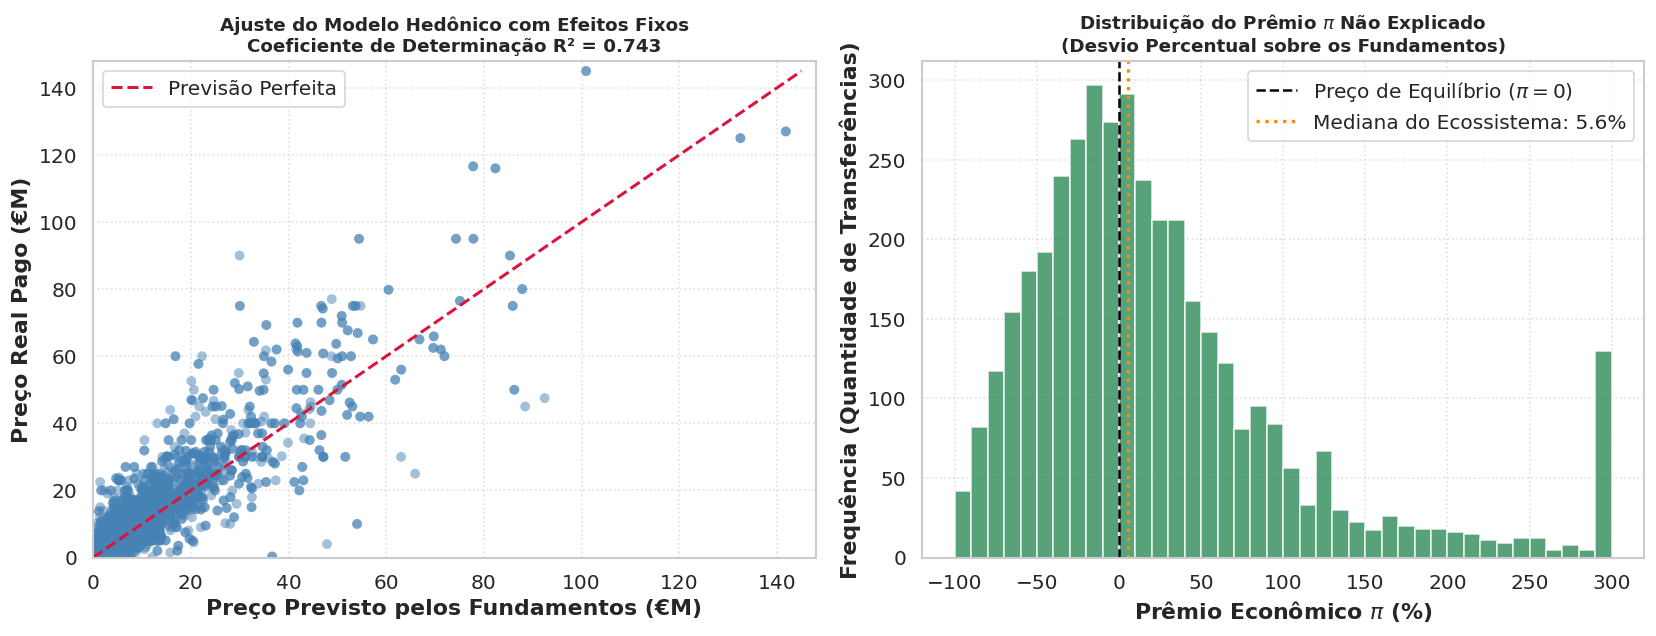

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
fee_real_m = np.expm1(y) / 1e6
fee_pred_m = np.expm1(y_pred) / 1e6

ax.scatter(fee_pred_m, fee_real_m, alpha=0.5, color='steelblue', s=35, edgecolor='none')

lim_max = max(fee_real_m.max(), fee_pred_m.max())
ax.plot([0, lim_max], [0, lim_max], color='crimson', linestyle='--', lw=1.8, label='Previsão Perfeita')

ax.set_xlim(0, lim_max * 1.02)
ax.set_ylim(0, lim_max * 1.02)
ax.set_xlabel('Preço Previsto pelos Fundamentos (€M)', fontweight='bold')
ax.set_ylabel('Preço Real Pago (€M)', fontweight='bold')
ax.set_title(f'Ajuste do Modelo Hedônico com Efeitos Fixos\nCoeficiente de Determinação R² = {model_ols.rsquared:.3f}', 
             fontsize=11, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, linestyle=':', alpha=0.6)

ax = axes[1]
mediana_premio = df_reg_base['pi_premio_pct'].median()

ax.hist(df_reg_base['pi_premio_pct'].clip(-100, 300), bins=40,
        color='seagreen', edgecolor='white', alpha=0.8)
ax.axvline(0, color='black', lw=1.5, linestyle='--', label='Preço de Equilíbrio ($\pi = 0$)')
ax.axvline(mediana_premio, color='darkorange', lw=2, linestyle=':',
           label=f'Mediana do Ecossistema: {mediana_premio:.1f}%')

ax.set_xlabel('Prêmio Econômico $\pi$ (%)', fontweight='bold')
ax.set_ylabel('Frequência (Quantidade de Transferências)', fontweight='bold')
ax.set_title('Distribuição do Prêmio $\pi$ Não Explicado\n(Desvio Percentual sobre os Fundamentos)', 
             fontsize=11, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## 10. Sumário e conclusões sobre metodologia

In [86]:
clubes_vendedores_unicos = df_pi_in[df_pi_in['sold_in_window'] == True]['buyer'].nunique()
summary = {
    'Total de transferências (Base Geral)': len(df_transfers),
    'Transfers com fee e MV válidos (N da análise)': len(df_pi_in),
    'Fee mediano do ecossistema (€M)': round(df_pi_in["fee"].median() / 1e6, 2),
    'Fee médio do ecossistema (€M)': round(df_pi_in["fee"].mean() / 1e6, 2),
    'Prêmio π mediano global (%)': round(df_pi_in["pi_pct"].median(), 1),
    'Prêmio π médio global (%)': round(df_pi_in["pi_pct"].mean(), 1),
    '% com π > 0 (pagou acima do fundamento MV)': f"{(df_pi_in['pi_pct'] > 0).mean() * 100:.0f}%",
    'Clubes compradores que também venderam na janela': clubes_vendedores_unicos,
    'π mediano: clubes que VENDERAM na janela (%)': round(grupo_vendeu.median(), 1),
    'π mediano: clubes que NÃO VENDERAM na janela (%)': round(grupo_nao_vendeu.median(), 1),
    'R² do modelo hedônico (com Efeitos Fixos)': round(model_ols.rsquared, 3),
}
for k, v in summary.items():
    print(f'{k:<52s} : {v}')

Total de transferências (Base Geral)                 : 16215
Transfers com fee e MV válidos (N da análise)        : 2488
Fee mediano do ecossistema (€M)                      : 3.8
Fee médio do ecossistema (€M)                        : 9.11
Prêmio π mediano global (%)                          : -6.1
Prêmio π médio global (%)                            : 29.8
% com π > 0 (pagou acima do fundamento MV)           : 42%
Clubes compradores que também venderam na janela     : 158
π mediano: clubes que VENDERAM na janela (%)         : -6.0
π mediano: clubes que NÃO VENDERAM na janela (%)     : -20.0
R² do modelo hedônico (com Efeitos Fixos)            : 0.743
